## Query header - Gen3

In this notebook, we show several ways to query the fits headers\
Craig Lage - 16-Mar-21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
import lsst.daf.butler as dafButler
import lsst.afw.cameraGeom.utils as camGeomUtils
import lsst.afw.display as afwDisplay

In [2]:
# Gen3 butler
# Making progress.  This is now faster than Gen2
REPO_DIR = '/readonly/lsstdata/auxtel/base/auxtel/oods/gen3butler/repo'
butler = dafButler.Butler(REPO_DIR, collections="LATISS/raw/all")

exposureList = []
for record in butler.registry.queryDimensionRecords("exposure", where="exposure.day_obs=20210311"):
    print(record.id, record.observation_type, record.exposure_time, record.physical_filter, record.target_name)
    exposureList.append(record.id)

2021031100001 bias 0.0 RG610~empty Park position
2021031100002 bias 0.0 RG610~empty Park position
2021031100003 bias 0.0 RG610~empty Park position
2021031100004 bias 0.0 RG610~empty Park position
2021031100005 bias 0.0 RG610~empty Park position
2021031100006 bias 0.0 RG610~empty Park position
2021031100007 bias 0.0 RG610~empty Park position
2021031100008 bias 0.0 RG610~empty Park position
2021031100009 bias 0.0 RG610~empty Park position
2021031100010 bias 0.0 RG610~empty Park position
2021031100011 bias 0.0 RG610~empty Park position
2021031100012 bias 0.0 RG610~empty Park position
2021031100013 bias 0.0 RG610~empty Park position
2021031100014 bias 0.0 RG610~empty Park position
2021031100015 bias 0.0 RG610~empty Park position
2021031100016 bias 0.0 RG610~empty Park position
2021031100017 bias 0.0 RG610~empty Park position
2021031100018 bias 0.0 RG610~empty Park position
2021031100019 bias 0.0 RG610~empty Park position
2021031100020 bias 0.0 RG610~empty Park position
2021031100021 bias 0

In [3]:
# To look at the header keywords
expId = 2021031100134
exp = butler.get('raw', detector=0, exposure=expId)
mData = exp.getMetadata()
for key in mData.keys():
    print(key, mData[key])

SIMPLE True
EXTEND True
COMMENT ---- Geometry from Camera ----
ORIGIN LSST DM Header Service
TIMESYS TAI
DATE 2021-03-12T00:10:07.696
DATE-OBS 2021-03-12T00:10:21.839
DATE-BEG 2021-03-12T00:10:21.839
DATE-END 2021-03-12T00:10:42.067
MJD 59285.007033522
MJD-OBS 59285.0071972079
MJD-BEG 59285.0071972079
MJD-END 59285.007431335
OBSID AT_O_20210311_000134
GROUPID 2021-03-12T00:09:54.060
IMGTYPE ENGTEST
BUNIT adu
FACILITY Vera C. Rubin Observatory
TELESCOP LSST AuxTelescope
INSTRUME LATISS
OBSERVER LSST
OBS-LONG -70.749417
OBS-LAT -30.244639
OBS-ELEV 2663.0
OBSGEO-X 1818938.94
OBSGEO-Y -5208470.95
OBSGEO-Z -3195172.08
RA 127.987259583333
DEC -39.0662630555556
RASTART 127.832958416612
DECSTART -39.0666520079601
RAEND 127.833019383891
DECEND -39.0666781801359
ROTPA -12.588471958761
ROTCOORD sky
HASTART -1.77542920900492
ELSTART 66.5308650418156
AZSTART 119.328628708114
AMSTART 1.08995905509075
HAEND -1.76912157017676
ELEND 66.5999368413322
AZEND 119.371991981257
AMEND 1.08937396910625
INSTPOR

In [4]:
# This also works, but the above is faster
for exposure in exposureList:
    mData = butler.get('raw.metadata', detector=0, exposure=exposure)
    expTime = mData['EXPTIME']
    imgType = mData['IMGTYPE']
    obj = mData['OBJECT']
    print(exposure, expTime, imgType, obj)

2021031100001 0.0 BIAS Park position
2021031100002 0.0 BIAS Park position
2021031100003 0.0 BIAS Park position
2021031100004 0.0 BIAS Park position
2021031100005 0.0 BIAS Park position
2021031100006 0.0 BIAS Park position
2021031100007 0.0 BIAS Park position
2021031100008 0.0 BIAS Park position
2021031100009 0.0 BIAS Park position
2021031100010 0.0 BIAS Park position
2021031100011 0.0 BIAS Park position
2021031100012 0.0 BIAS Park position
2021031100013 0.0 BIAS Park position
2021031100014 0.0 BIAS Park position
2021031100015 0.0 BIAS Park position
2021031100016 0.0 BIAS Park position
2021031100017 0.0 BIAS Park position
2021031100018 0.0 BIAS Park position
2021031100019 0.0 BIAS Park position
2021031100020 0.0 BIAS Park position
2021031100021 0.0 BIAS Park position
2021031100022 0.0 BIAS Park position
2021031100023 0.0 BIAS Park position
2021031100024 0.0 BIAS Park position
2021031100025 0.0 BIAS Park position
2021031100026 0.0 BIAS Park position
2021031100027 0.0 BIAS Park position
2

KeyboardInterrupt: 

In [5]:
expId = 2021031100134
exp = butler.get('raw', detector=0, exposure=expId)

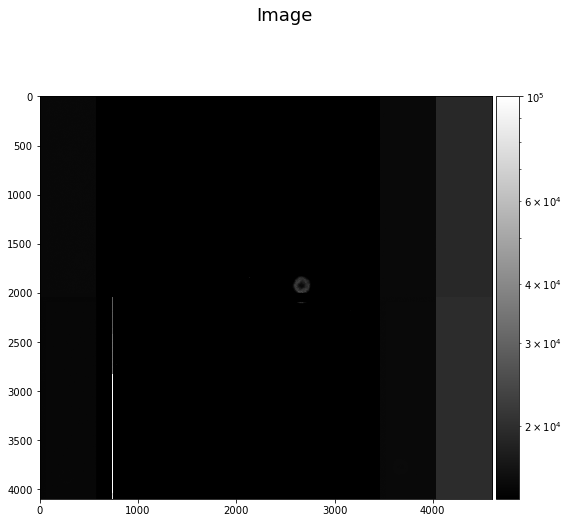

In [6]:
# Look at the data with matplotlib
# The raw data doesn't look very good, because of the large pedestal of about 15,000 ADU
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image",fontsize=18)
arr = exp.image.array
img = plt.imshow(arr, norm=LogNorm(vmin=14000, vmax=100000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")

In [7]:
# Gen3 butler
# Making progress.  This is now faster than Gen2
REPO_DIR = '/readonly/lsstdata/comcam/base/comcam/oods/gen3butler/repo'
butler = dafButler.Butler(REPO_DIR, collections="LSSTComCam/raw/all")

exposureList = []
for record in butler.registry.queryDimensionRecords("exposure", where="exposure.day_obs=20210402"):
    print(record.id, record.observation_type, record.exposure_time, record.physical_filter, record.target_name)
    exposureList.append(record.id)

2021040200001 dark 100.0 i_06 UNKNOWN
2021040200002 dark 100.0 i_06 UNKNOWN
2021040200003 dark 100.0 i_06 UNKNOWN
2021040200004 dark 100.0 i_06 UNKNOWN
2021040200005 dark 100.0 i_06 UNKNOWN
2021040200006 dark 100.0 i_06 UNKNOWN
2021040200007 dark 100.0 i_06 UNKNOWN
2021040200008 dark 100.0 i_06 UNKNOWN
2021040200009 dark 100.0 i_06 UNKNOWN
2021040200010 flat 5.0 i_06 UNKNOWN
2021040200011 flat 5.0 i_06 UNKNOWN
2021040200012 flat 5.0 i_06 UNKNOWN
2021040200013 flat 5.0 i_06 UNKNOWN
2021040200014 flat 5.0 i_06 UNKNOWN
2021040200015 flat 5.0 i_06 UNKNOWN
2021040200016 flat 5.0 i_06 UNKNOWN
2021040200017 flat 5.0 i_06 UNKNOWN
2021040200018 flat 5.0 i_06 UNKNOWN
2021040200019 flat 5.0 i_06 UNKNOWN
2021040200020 bias 0.0 i_06 UNKNOWN
2021040200021 bias 0.0 i_06 UNKNOWN
2021040200022 bias 0.0 i_06 UNKNOWN
2021040200023 bias 0.0 i_06 UNKNOWN
2021040200024 bias 0.0 i_06 UNKNOWN
2021040200025 flat 1.0 i_06 UNKNOWN
2021040200026 flat 1.0 i_06 UNKNOWN
2021040200027 flat 2.0 i_06 UNKNOWN
2021040200

In [8]:
# To look at the header keywords
expId = 2021040200005
exp = butler.get('raw', detector=0, exposure=expId)
mData = exp.getMetadata()
for key in mData.keys():
    print(key, mData[key])

SIMPLE True
EXTEND True
COMMENT ---- Checksums ----
ORIGIN LSST DM Header Service
TIMESYS TAI
DATE 2021-04-02T12:09:42.194
DATE-OBS 2021-04-02T12:08:36.385
DATE-BEG 2021-04-02T12:08:36.385
DATE-END 2021-04-02T12:10:16.393
MJD 59306.5067383619
MJD-OBS 59306.5059766764
MJD-BEG 59306.5059766764
MJD-END 59306.507134175
OBSID CC_O_20210402_000005
GROUPID CALSET_20210402_1158
IMGTYPE DARK
BUNIT adu
FACILITY Vera C. Rubin Observatory
TELESCOP Simonyi Survey Telescope
INSTRUME ComCam
OBSERVER LSST
OBS-LONG -70.749417
OBS-LAT -30.244639
OBS-ELEV 2663.0
OBSGEO-X 1818938.94
OBSGEO-Y -5208470.95
OBSGEO-Z -3195172.08
RA None
DEC None
RASTART None
DECSTART None
RAEND None
DECEND None
ROTPA None
ROTCOORD sky
HASTART None
ELSTART 78.0
AZSTART 45.0
AMSTART None
HAEND None
ELEND 78.0
AZEND 45.0
AMEND None
TRACKSYS None
RADESYS None
FOCUSZ None
OBJECT None
CAMCODE CC
CONTRLLR O
DAYOBS 20210402
SEQNUM 5
TESTTYPE DARK
TSTAND None
IMAGETAG aa1a9f19491077c3
OBSANNOT standardCal
FILTBAND i
FILTER i_06
FILTSLO

In [10]:
expId = 2021040200031
exp = butler.get('raw', detector=0, exposure=expId)

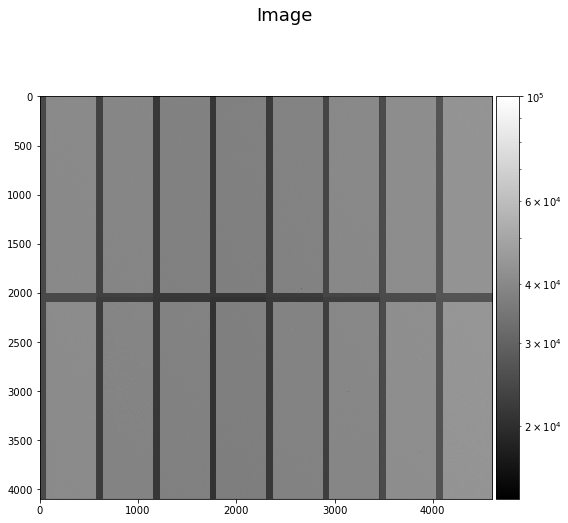

In [11]:
# Look at the data with matplotlib
# The raw data doesn't look very good, because of the large pedestal of about 15,000 ADU
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image",fontsize=18)
arr = exp.image.array
img = plt.imshow(arr, norm=LogNorm(vmin=14000, vmax=100000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")